# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [2]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency


### Cargar Dataset

In [3]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [11]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- "nivel_ingreso"
- "visitas_mes"
- "compras_mes"
- "gasto_publicidad_dirigida"
- "satisfaccion"
- "ingreso_anual"

La mayoría de estas variables presentan tipos de datos adecuados.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [12]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [13]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` presenta una distribucion normal. existe simetria. no hay valores fuera de rango
- "nivel_ingreso" presenta una distribucion normal. existe simetria.
- "visitas_mes" hay un rango importante entre el min y max de visitas. 1-25
- "compras_mes" 25% de los clientes no generan ingresos actualmente.
- "gasto_publicidad_dirigida" el rango entre media y max es considerable. se requiere mayor analisis en la efectividad del gasto respecto a la conversion de compra.
- "abandono" 15% de los clientes abandonan el marketplace
- "miembro_premium" 14% de los clientes tienen la membresia premium


#### Explorar variables binarias

In [ ]:
# Verificar que cada columna tenga únicamente dos valores posibles


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- "abandono" 15% de los clientes abandonan el marketplace
- "miembro_premium" 14% de los clientes tienen la membresia premium

#### Explorar variables categóricas

In [14]:
# Verificar el número de valores únicos por variable categórica
unicos_region = df["region"].nunique()
unicos_dispositivo = df["tipo_dispositivo"].nunique()
print(unicos_region)
print(unicos_dispositivo)

4
3


In [15]:
# Explorar variables categóricas y cómo se distribuyen
columnas_categoricas = ["region", "tipo_dispositivo"]
df[columnas_categoricas].describe()

,region,tipo_dispositivo
count,15000,15000
unique,4,3
top,norte,móvil
freq,4395,9818


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — el dispositivo movil se usa con mas frecuencia por los clientes
- "region" la region "norte" tiene registrados mas clientes


### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

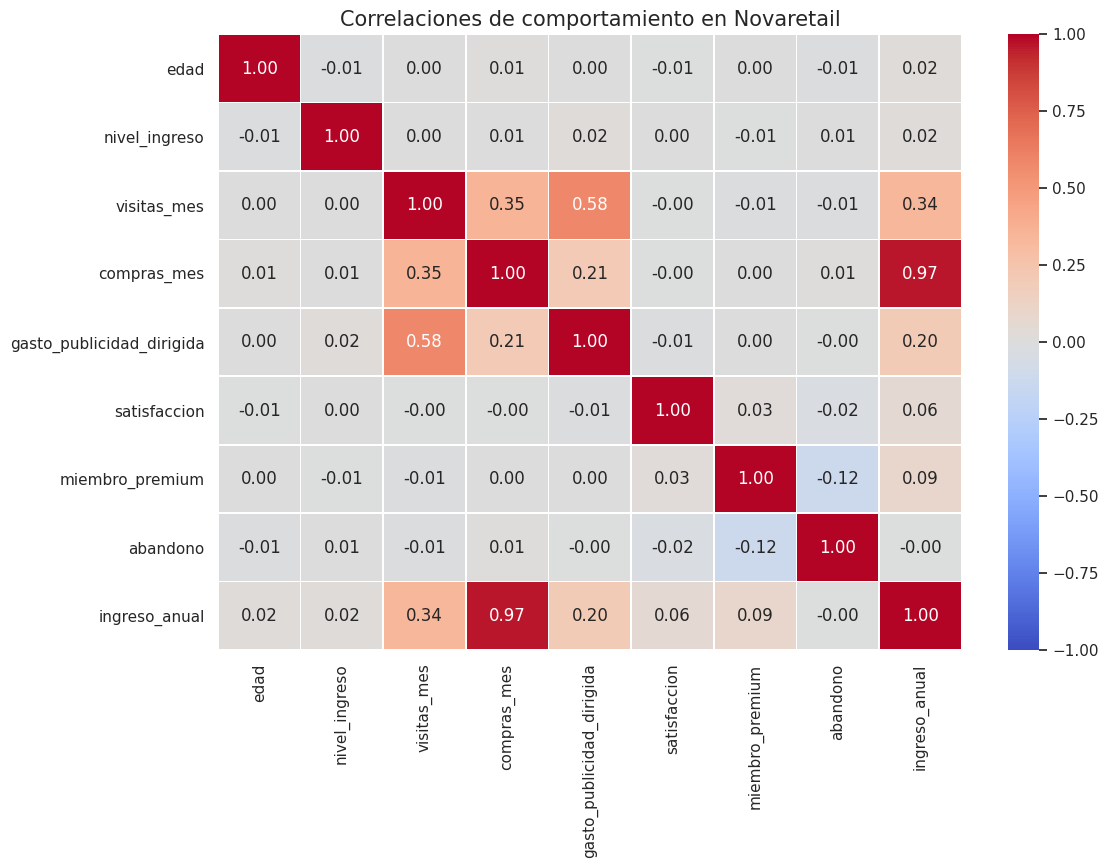

In [16]:
# Visualizar la matriz de correlación para identificar relaciones
plt.figure(figsize=(12,8))
matriz_corr = df.corr()
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlaciones de comportamiento en Novaretail", fontsize=15)
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa una correlacion positiva entre las variables gasto_publicidad_dirigida vs visitas_mes, lo que puede indicar que el gasto en publicidad, esta trayendo mas visitas, aunque la relacion se va debilitando con otras variables como "ingreso_anual"


Observaciones respecto a `ingreso_anual`  
- Presenta una correlacion moderada con visitas_mes, lo que indicaria que entre mas visitas de los clientes, hay una tendencia a que estos clientes hagan una compra.


### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

### Scatterplot para pares clave

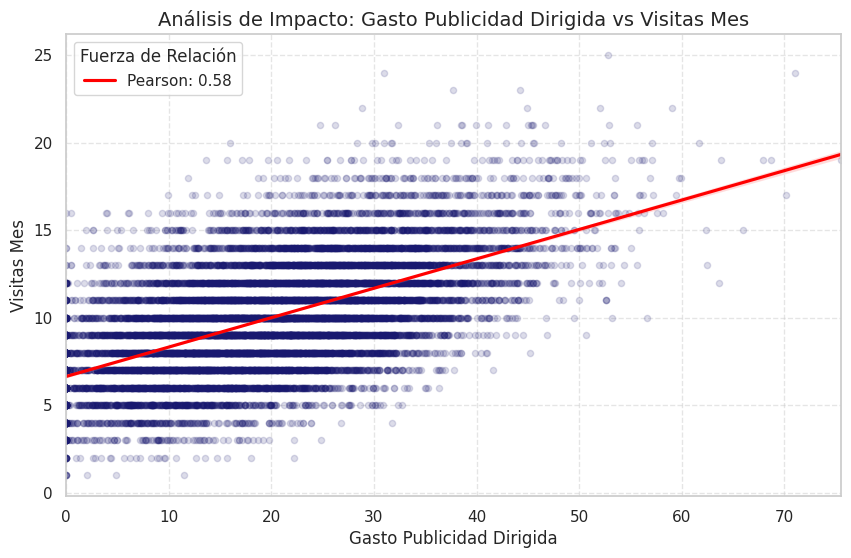

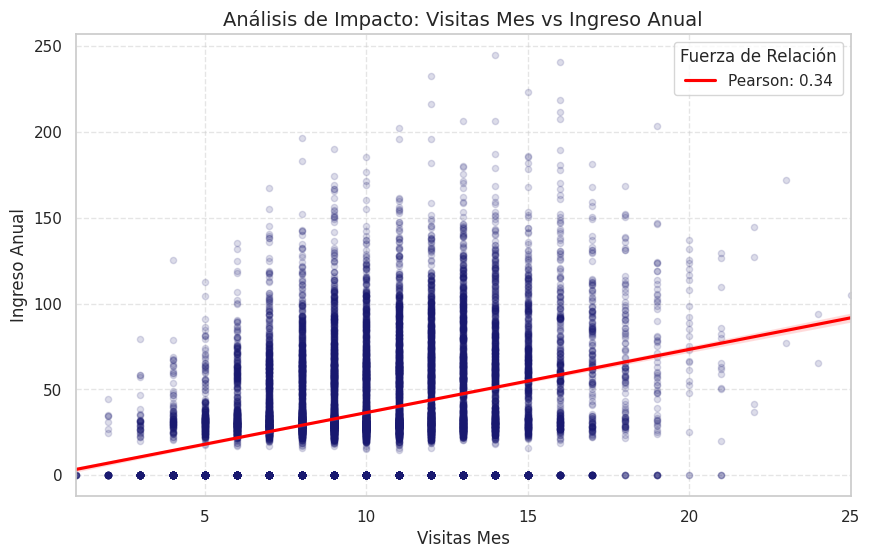

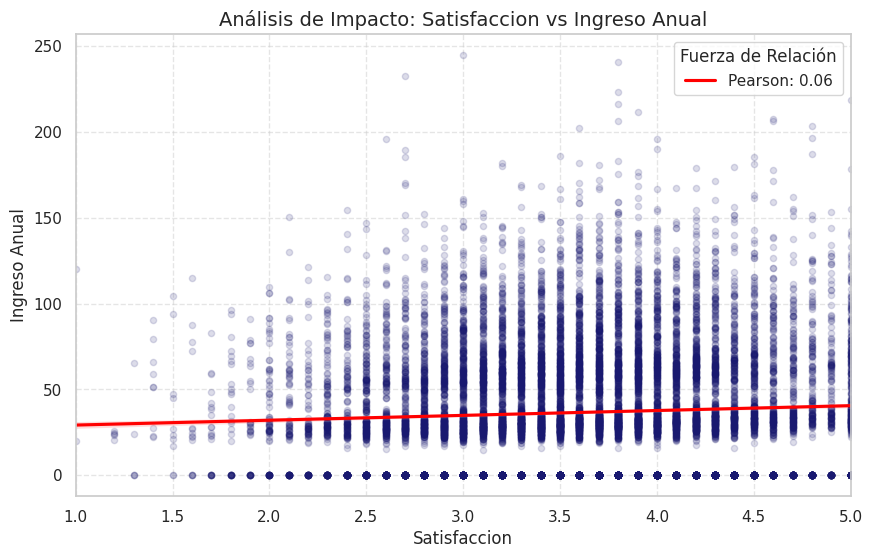

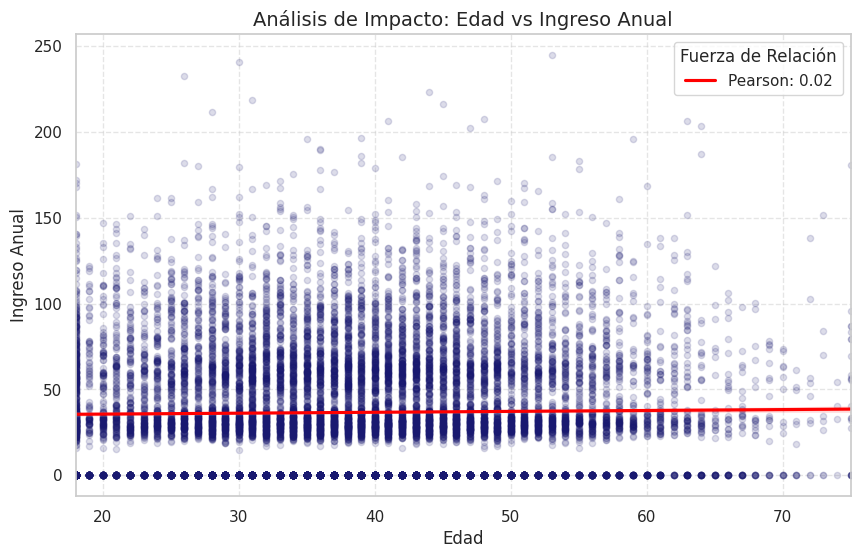

In [17]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

def scatter_relacion(df, x_col, y_col):
    
    corr_p = df[x_col].corr(df[y_col])
    
    plt.figure()
    sns.regplot(
        data=df, x=x_col, y=y_col,
        scatter_kws={'alpha': 0.15, 'color': 'midnightblue', 's': 20},
        line_kws={'color': 'red', 'label': f'Pearson: {corr_p:.2f}'}
    )
    
    plt.title(f"Análisis de Impacto: {x_col.replace('_', ' ').title()} vs {y_col.replace('_', ' ').title()}", fontsize=14)
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel(y_col.replace('_', ' ').title())
    plt.legend(title="Fuerza de Relación")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

pares_clave = [
    ('gasto_publicidad_dirigida', 'visitas_mes'),
    ('visitas_mes', 'ingreso_anual'),            
    ('satisfaccion', 'ingreso_anual'),           
    ('edad', 'ingreso_anual')                    
]

for x, y in pares_clave:
    scatter_relacion(df, x, y)

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**Gasto_publicidad_dirigida vs visits_mes**
- Dirección positiva
- existe una correlacion fuerte, pero el gasto en publicidad no es el unico "driver" de visitas. 

**ingreso_anual vs visitas_mes**
- Dirección positiva
- existe correlacion moderada-baja. los datos sugieren que en limites extremos de visitas, los clientes tienden a convertir menos.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [6]:
# Calcular correlación entre variables relevantes

pearson = df["gasto_publicidad_dirigida"].corr(df["visitas_mes"], method="pearson")
spearman = df["gasto_publicidad_dirigida"].corr(df["visitas_mes"], method="spearman")
print(f"--- Auditoria de eficiencia en gasto publicitario ---")
print(f"Coeficiente de Pearson: {pearson:.4f}")
print(f"Coeficiente de Spearman: {spearman:.4f}")


--- Auditoria de eficiencia en gasto publicitario ---
Coeficiente de Pearson: 0.5789
Coeficiente de Spearman: 0.5593


In [7]:
# Calcular correlación entre variables relevantes
pearson_2 = df["visitas_mes"].corr(df["compras_mes"], method="pearson")
spearman_2 = df["visitas_mes"].corr(df["compras_mes"], method="spearman")
print(f"--- Auditoria de conversion ---")
print(f"Coeficiente de Pearson: {pearson_2:.4f}")
print(f"Coeficiente de Spearman: {spearman_2:.4f}")


--- Auditoria de conversion ---
Coeficiente de Pearson: 0.3538
Coeficiente de Spearman: 0.3329


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**visitas_mes vs gasto_publicitario**
- Correlación es fuerte. entre mas gasto en publicidad hay mas visitas.
- 

**compras_mes vs visitas_mes**
- Correlación es leve/moderada. sugiere una friccion en el marketplace, ya sea por experiencia de usuario, disponibilidad del producto o tiempos de entrega elevados.
- 

### Punto-biserial

In [13]:
# Calcular correlación entre variables relevantes
coef_premium = df["miembro_premium"].corr(df["ingreso_anual"])
print(f"Correlacion punto-biserial(miembro_premium vs ingreso_anual: {coef_premium:.4f}")

coef_abandono = df["abandono"].corr(df["ingreso_anual"])
print(f"Correlacion punto-biserial(abandono vs ingreso_anual: {coef_abandono:.4f}")

Correlacion punto-biserial(miembro_premium vs ingreso_anual: 0.0931
Correlacion punto-biserial(abandono vs ingreso_anual: -0.0028


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**
- Relación positiva, aunque debil. la membresia premium no influye significativamente en la incidencia de compra.

**abandono vs ingreso_anual**
- Relación negativa, practicamente nula. los clientes no son sensibles a abandonar por tener incidencia de compras. pueden abandonar sin haber comprado o haber realizado compras en la plataforma.

### V de Cramér

In [14]:
# Función para calcular V de Cramér
def cramer_v(x,y):
    matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(matrix)[0]
    n = matrix.sum().sum()
    phi2 = chi2/n
    r, k = matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr/min((kcorr-1),(rcorr-1)))

In [18]:
# Aplicar V de Cramér en variables relevantes
v_region = cramer_v(df["abandono"], df["region"])
v_dispositivo = cramer_v(df["abandono"], df["tipo_dispositivo"])
v_region_dispositivo = cramer_v(df["tipo_dispositivo"], df["region"])

print(f"V de Cramer (Abandono vs region): {v_region:.4f}")
print(f"V de Cramer (Abandono vs tipo_dispositivo): {v_dispositivo:.4f}")
print(f"V de Cramer (region vs tipo_dispositivo): {v_region_dispositivo:.4f}")


V de Cramer (Abandono vs region): 0.0062
V de Cramer (Abandono vs tipo_dispositivo): 0.0000
V de Cramer (region vs tipo_dispositivo): 0.0000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér se concentro el analisis en descrifrar si hay alguna correlacion de alguna variable con el abandono de los clientes. el analisis, con base en las medidas estadisticas. muestra que el abandono no tiene correlacion con alguna variable especifica

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — Diagnostico del Embudo

**Evidencia visual:** Scatterplot publicidad vs visitas. muestra una dispersion clara con una tendencia positiva. se detalla el coeficiente de correlacion, confirmando el grafico con el calculo. Se compara con scatterplot de "visitas_mes vs ingreso_anual"
**Evidencia numérica:** Pearson= 0.58 para publicidad vs visitas y Pearson= 0.35 para visitas vs ingreso_anual

**Interpretación**  
La correlacion indica que marketing esta cumpliendo el indicador de atraer trafico calificado. sin embargo, el usuario en el marketplace encuentra friccion para convertir.

**No podemos afirmar**  
Que la publicidadno este dirigida al segmento correcto. el trafico es calificado, ya que aumentan las visitas en relacion con el gasto en publicidad.

**Implicación de negocio**  
La friccion en el marketplace puede estar "quemando" el gasto en publicidad. ya que existe el interes de compra(trafico), pero no se estan concretando las ventas. se sugiere hacer pruebas UX para determinar ¡cual es la friccion en el marketplace?

### Hallazgo 2 — Razon de abandono de clientes

**Evidencia visual:**   
**Evidencia numérica:** el calculo del coeficiente de correlacion "v de cramer" = 0.0000

**Interpretación**  
El comportamiento de los clientes y su riesgo de abandono es homogeneo. no hay alguna correlacion por region o tipo de dispositivo que pueda indicar algun fallo operativo o regional

**No podemos afirmar**  
Que la interaccion de los clientes con la plataforma no tenga fallas. Si hay alguna friccion o problema, afecta a todos los usuarios por igual, cualquier region o tipo de dispositivo

**Implicación de negocio**  
El abandono se presenta como un indicador de indiferencia de los clientes. lo mas probable es que sea el marketplace. 

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### **Limitaciones**
- Se observa que el gasto en publicidad y las visitas tienen una correlacion fuerte, pero al momento de convertir, la correlacion disminuye. para confirmar causalidad, se requieren pruebas controladas

### **Próximos pasos** 
- Proyectar escenarios en los que se determine la cantidad de ingresos que tendria NovaRetail en caso de que la correlacion entre gasto_publicitario e ingreso_anual aumente de 0.35 a 0.50
- Confirmar causalidad con pruebas controladas, tipo A/B.
- Hacer una exploracion detallada de los clientes que estan haciendo compras. es la satisfaccion? es el dispositivo? influye el gasto en publicidad?